# Week 2 Assignment -- Classical Machine Learning
**Topics Covered :**  

1. **Data Preprocessing & EDA:** Distribution visualizations, summary statistics, and anomaly assessment.
2. **Time Series Diagnostics:** Seasonal decomposition (Additive/Multiplicative), Box-Cox transformations, and Augmented Dickey-Fuller tests.
3. **Group-Based Feature Engineering:** Datetime components, grouped sequential lags, and moving rolling statistics.
4. **Leakage-Safe Pipelines:** Integrated 'ColumnTransformer' (One-Hot Encoding + Standard Scaling) paired with multi-model scikit-learn architectures.
5. **Rigorous Validation:** 'TimeSeriesSplit' cross-validation, 'GridSearchCV' hyperparameter tuning, and comprehensive error analysis (MAE, MSE, RMSE, R²).
6. **Univariate Trend Forecasting:** Macro-level forecasting using statistical ARIMA modeling.


This section imports all required Python libraries for data analysis, visualization, machine learning, and forecasting.

In [ ]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import GridSearchCV
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,OrdinalEncoder
from sklearn.model_selection import cross_val_score,TimeSeriesSplit, GridSearchCV,train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

The dataset is loaded into a Pandas DataFrame for further analysis and processing.

In [ ]:
#Load Dataset
df = pd.read_csv("/content/tesla_deliveries_dataset_2015_2025.csv")
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


This section provides basic information about the dataset including its dimensions, data types, summary statistics, and missing values.

In [ ]:
#Dataset overview
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


## Exploratory Data Analysis – Categorical Features

Categorical variables are analyzed to understand the frequency distribution of different categories present in the dataset.
### Count Plots

Count plots help visualize how frequently each category appears in the dataset.

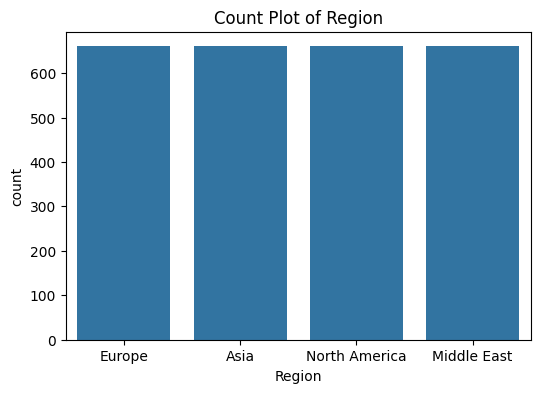

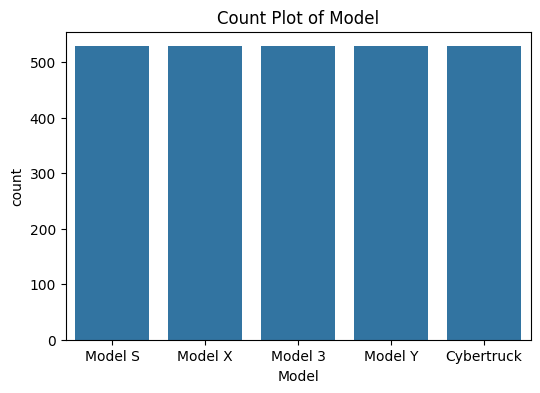

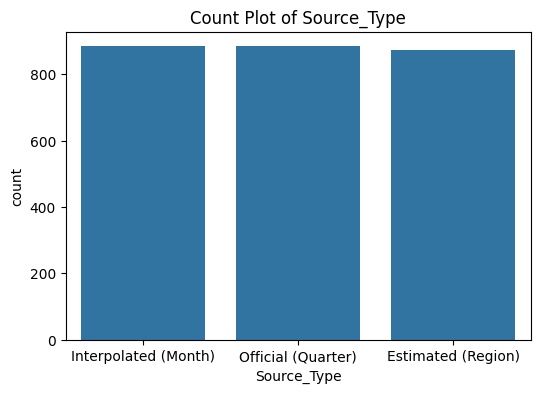

In [ ]:
#EDA for categorical columns
cat_cols = ['Region', 'Model', 'Source_Type']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.title(f'Count Plot of {col}')
    plt.show()

### Pie Charts

Pie charts show the percentage contribution of each category within a feature.

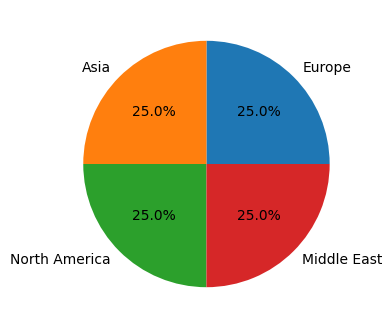

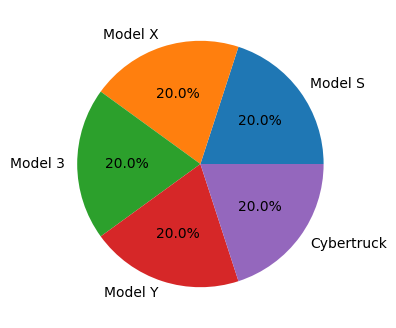

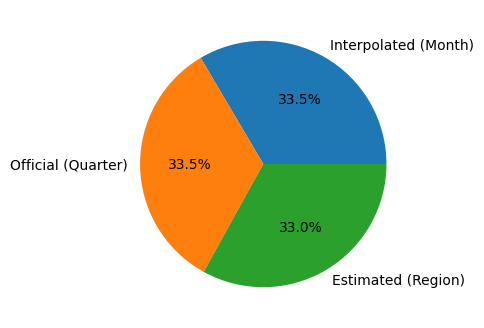

In [ ]:
cat_cols = ['Region', 'Model', 'Source_Type']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts().plot(kind='pie',autopct='%1.1f%%')
    plt.ylabel('')
    plt.show()

## Exploratory Data Analysis – Numerical Features
Numerical variables are explored to understand their distributions, ranges, and patterns.
### Histograms

Histograms display the distribution of numerical features and help identify skewness, spread, and concentration of values.

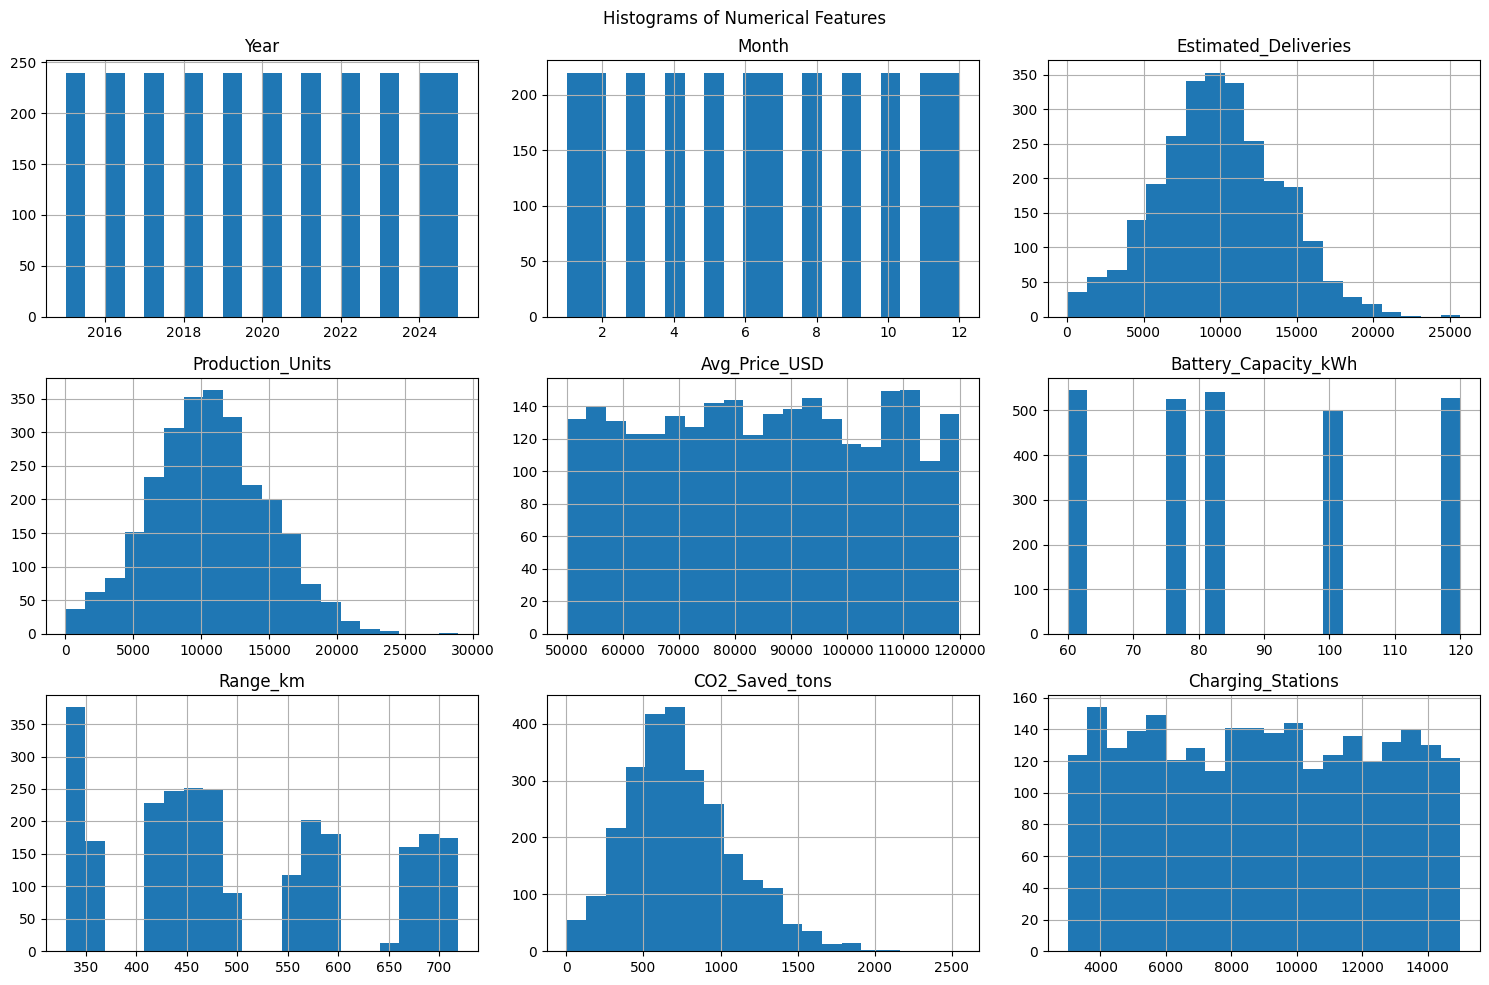

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(15,10), bins=20)
plt.suptitle("Histograms of Numerical Features")
plt.tight_layout()
plt.show()

### Box Plots

Box plots are used to visualize the spread of data and detect potential outliers in numerical features.

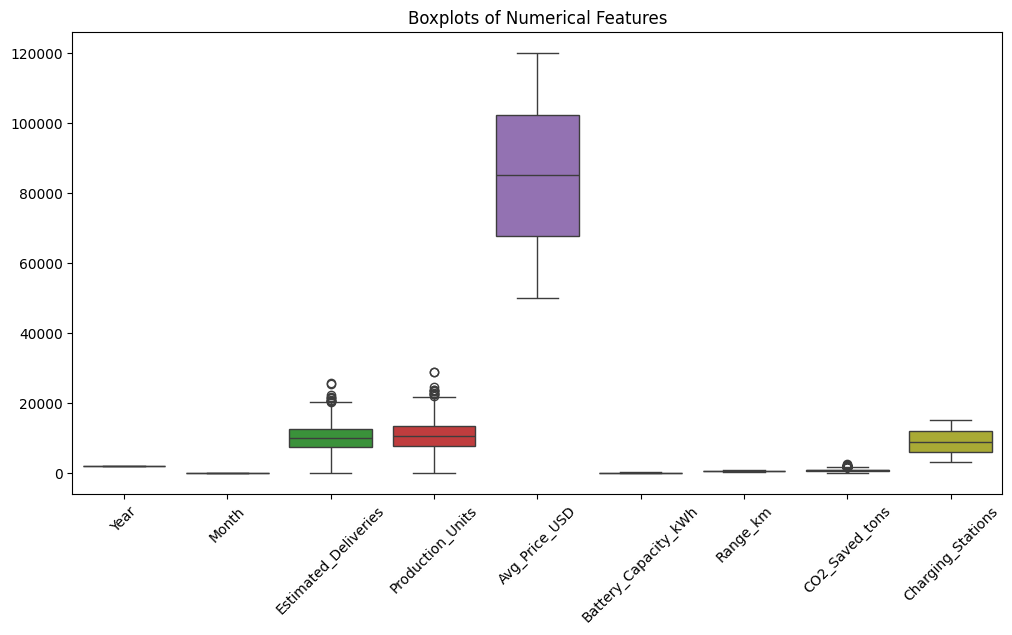

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(df[num_cols])
plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Features")
plt.show()


# **Time series analysis**

It requires observations to be ordered chronologically.
In this step, we combine the Year and Month columns to create a proper Date column and sort the dataset by time.

This enables temporal analysis, forecasting, and feature engineering based on historical observations.

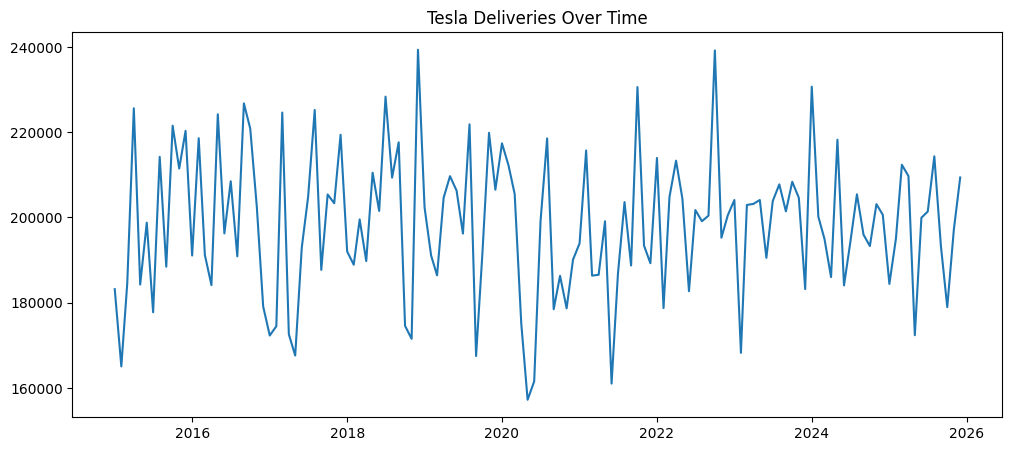

In [ ]:
df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-" +df["Month"].astype(str))
df = df.sort_values("Date")

ts = (df.groupby("Date")["Estimated_Deliveries"].sum().reset_index())
ts.set_index("Date", inplace=True)

plt.figure(figsize=(12,5))
plt.plot(ts)
plt.title("Tesla Deliveries Over Time")
plt.show()

# Additive Time Series Decomposition

A time series often consists of multiple components:

1. Trend
2. Seasonality
3. Residual Noise

Additive decomposition assumes:

Observed = Trend + Seasonality + Residual

This method is useful when seasonal fluctuations remain relatively constant over time.

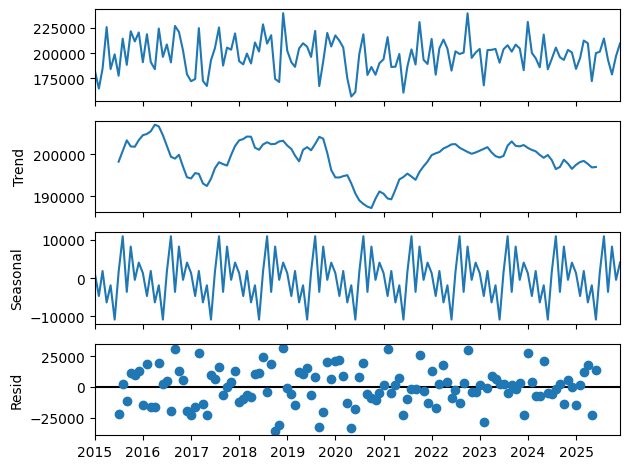

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
additive = seasonal_decompose(ts,model="additive",period=12)
additive.plot()
plt.show()

# Multiplicative Time Series Decomposition

Multiplicative decomposition assumes:

Observed = Trend × Seasonality × Residual

This approach is more suitable when seasonal variations increase or decrease proportionally with the level of the series.

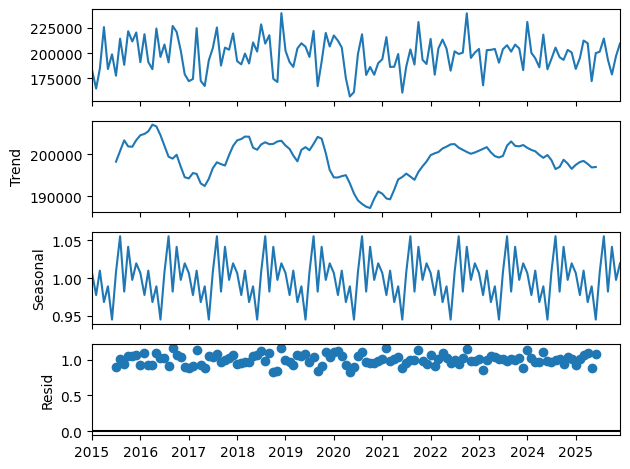

In [ ]:
multiplicative = seasonal_decompose(ts,model="multiplicative",period=12)
multiplicative.plot()
plt.show()

# Box-Cox Transformation

Many forecasting models perform better when the variance of the series remains stable over time.

The Box-Cox transformation stabilizes variance, making the data more suitable for statistical modeling and forecasting.

Lambda = 1.1588680410120005


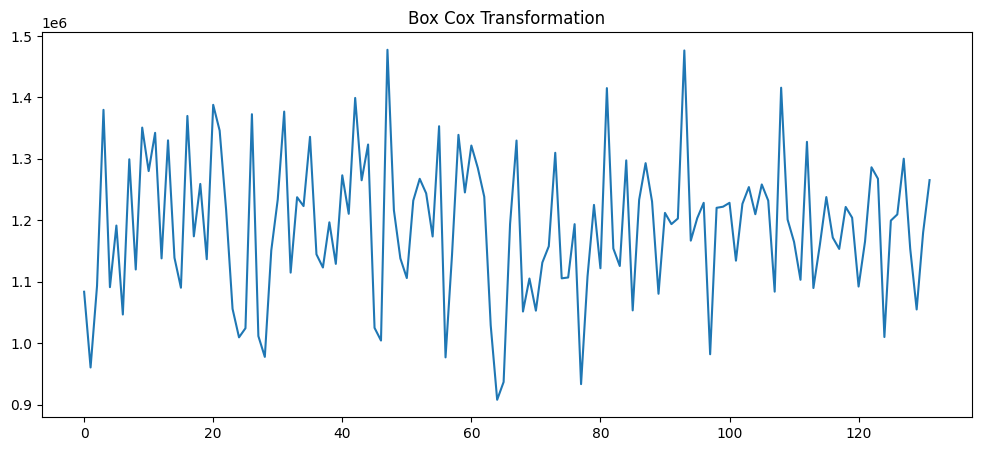

In [ ]:
from scipy.stats import boxcox
ts_boxcox, lam = boxcox(ts["Estimated_Deliveries"])
print("Lambda =", lam)
plt.figure(figsize=(12,5))
plt.plot(ts_boxcox)
plt.title("Box Cox Transformation")
plt.show()

# Augmented Dickey-Fuller (ADF) Test

Stationarity is one of the most important assumptions in time series forecasting.

A stationary series has:
- Constant mean
- Constant variance
- Constant autocorrelation structure

The ADF test is used to determine whether the time series is stationary.

In [ ]:
from statsmodels.tsa.stattools import adfuller
# ADF Stationarity Test (Before vs After Differencing)
result_before = adfuller(ts["Estimated_Deliveries"])
print("ADF p-value (Before Diff):", result_before[1])

ts_diff = ts["Estimated_Deliveries"].diff().dropna()
result_after = adfuller(ts_diff)
print("ADF p-value (After Diff):", result_after[1])

ADF p-value (Before Diff): 1.3181396968154354e-14
ADF p-value (After Diff): 6.955769810310614e-10


# Date-Based Feature Engineering

Temporal patterns often repeat at specific intervals.

We extract:

- Month
- Quarter
- Year

These features help machine learning models identify recurring seasonal behaviors and long-term trends.

In [ ]:
# Time features
df["month"] = df["Date"].dt.month
df["quarter"] = df["Date"].dt.quarter
df["year_num"] = df["Date"].dt.year

# Creating Lag Features

Lag features allow the model to learn relationships between past and current delivery values.

- lag_1 → Previous month deliveries
- lag_3 → Deliveries three months ago
- lag_6 → Deliveries six months ago

# Rolling Window Statistics

Rolling statistics summarize recent historical behavior of the time series.
- Rolling Mean
- Rolling Standard Deviation

These features help capture short-term trends and fluctuations in Tesla deliveries.

In [ ]:
#Lag and rolling features MUST be calculated per unique group
group_cols = ['Region', 'Model', 'Source_Type']

df["lag_1"] = df.groupby(group_cols)["Estimated_Deliveries"].shift(1)
df["lag_3"] = df.groupby(group_cols)["Estimated_Deliveries"].shift(3)
df["lag_6"] = df.groupby(group_cols)["Estimated_Deliveries"].shift(6)

df["rolling_mean_3"] = df.groupby(group_cols)["Estimated_Deliveries"].transform(lambda x: x.rolling(3).mean())
df["rolling_std_3"] = df.groupby(group_cols)["Estimated_Deliveries"].transform(lambda x: x.rolling(3).std())

In [ ]:
# Remove rows having NaN values generated by lag/rolling features
df = df.dropna().reset_index(drop=True)

y = df['Estimated_Deliveries']
X = df.drop(columns=['Estimated_Deliveries', 'Date'])

# Clean split along chronological time (80% Train, 20% Test)
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

**Categorical encoding** is the process of converting non-numerical categorical data into numerical formats. Because most machine learning algorithms require numerical inputs, this step allows models to interpret and learn from textual or categorical features effectively

Some are:

->Label encoding

->One hot encoding

->Ordinal encoding

### Label Encoding

Label Encoding assigns a unique numerical value to each category within a feature.

(Here implemented only for understanding purpose)

In [ ]:
df_label=df.copy()
le=LabelEncoder()
for col in cat_cols:
    df_label[col] = le.fit_transform(df_label[col])
    print(f"{col}:")
    print(dict(zip(le.classes_, map(int, le.transform(le.classes_)))))
    print()

Region:
{'Asia': 0, 'Europe': 1, 'Middle East': 2, 'North America': 3}

Model:
{'Cybertruck': 0, 'Model 3': 1, 'Model S': 2, 'Model X': 3, 'Model Y': 4}

Source_Type:
{'Estimated (Region)': 0, 'Interpolated (Month)': 1, 'Official (Quarter)': 2}



### Ordinal Encoding

Ordinal Encoding converts categories into numerical values. It is generally used when categories have a meaningful order.

(Here implemented only for understanding purpose)

In [ ]:
df_ordinal = df.copy()
for col in cat_cols:
    oe = OrdinalEncoder()
    df_ordinal[[col]] = oe.fit_transform(df_ordinal[[col]])
    print(f"{col}:")
    categories = oe.categories_[0]
    for i, value in enumerate(categories):
        print(f"{value} -> {i}")
    print()

Region:
Asia -> 0
Europe -> 1
Middle East -> 2
North America -> 3

Model:
Cybertruck -> 0
Model 3 -> 1
Model S -> 2
Model X -> 3
Model Y -> 4

Source_Type:
Estimated (Region) -> 0
Interpolated (Month) -> 1
Official (Quarter) -> 2



## Machine Learning Pipeline
A machine learning pipeline combines multiple processing steps into a single workflow. It helps automate preprocessing and model training while reducing the risk of data leakage.

In this pipeline, feature scaling and Regression model are combined into one sequence of operations.

### One-Hot Encoding

One-Hot Encoding creates separate binary columns for each category, preventing the introduction of artificial ordering among categories.

### Feature Scaling
Feature scaling is applied to numerical features to bring them to a similar scale.
The scaler is fitted only on the training data to avoid data leakage and then applied to both training and testing datasets.

In [ ]:
from sklearn.compose import ColumnTransformer
# PIPELINING & ENCODING
cat_cols = ['Region', 'Model', 'Source_Type']
num_cols = [col for col in X.columns if col not in cat_cols]

# Build preprocessor bundle
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ])

#MODEL TRAINING
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lasso_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=10000, random_state=42))
])

ridge_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(random_state=42))
])


**A cross-validation (CV) score** in regression is a metric that measures how well a predictive model generalizes to unseen data. Rather than evaluating a model on the same data used to train it, cross-validation splits the data into multiple chunks.


In [ ]:
# Create the correct time-series cross-validation tool
tscv = TimeSeriesSplit(n_splits=5)

lr_scores = cross_val_score(lr_pipeline, X_train, y_train, cv=tscv, scoring='r2')
print("Linear Regression CV Scores:", lr_scores)
print("Mean Linear Regression CV Score:", lr_scores.mean())
print()

lasso_scores = cross_val_score(lasso_pipe, X_train, y_train, cv=tscv, scoring='r2')
print("Lasso CV Scores:", lasso_scores)
print("Mean Lasso CV Score:", lasso_scores.mean())
print()

ridge_scores = cross_val_score(ridge_pipe, X_train, y_train, cv=tscv, scoring='r2')
print("Ridge CV Scores:", ridge_scores)
print("Mean Ridge CV Score:", ridge_scores.mean())

Linear Regression CV Scores: [0.99024739 0.99000351 0.9914934  0.99049977 0.98929915]
Mean Linear Regression CV Score: 0.9903086448599818

Lasso CV Scores: [0.9902295  0.99005151 0.99153932 0.99061164 0.98934487]
Mean Lasso CV Score: 0.9903553685823704

Ridge CV Scores: [0.99015455 0.9901095  0.99149276 0.99049613 0.98931661]
Mean Ridge CV Score: 0.9903139097787687


## Hyperparameter Tuning
Hyperparameter tuning is the process of finding the best parameter values for a machine learning model. GridSearchCV is used to test multiple combinations and select the model with the best cross-validation performance.

GridSearchCV was used to identify the optimal regularization strength (alpha) for Ridge and Lasso Regression.

In [ ]:
# Tuning Ridge Regression
param_grid_ridge = {
    'model__alpha': [0.01, 0.1, 1, 10, 100]
}

grid_ridge = GridSearchCV(ridge_pipe, param_grid_ridge, cv=tscv, scoring='r2')
grid_ridge.fit(X_train, y_train)

print("Best Parameters for Ridge:", grid_ridge.best_params_)
print("Best CV Score for Ridge:", grid_ridge.best_score_)


Best Parameters for Ridge: {'model__alpha': 1}
Best CV Score for Ridge: 0.9903139097787687


In [ ]:
# Tuning Lasso Regression
param_grid_lasso = {
    'model__alpha': [0.01, 0.1, 1, 10, 100]
}
grid_lasso = GridSearchCV(lasso_pipe, param_grid_lasso, cv=tscv, scoring='r2')
grid_lasso.fit(X_train, y_train)

print("Best Parameters for Lasso:", grid_lasso.best_params_)
print("Best CV Score for Lasso:", grid_lasso.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.803e+06, tolerance: 5.228e+05
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.895e+06, tolerance: 1.987e+06
  model = cd_fast.enet_coordinate_descent(


Best Parameters for Lasso: {'model__alpha': 10}
Best CV Score for Lasso: 0.9904303378540178


**Evaluation metrics**

**MAE(Mean Absolute Error)** calculates the average of the absolute differences between actual and predicted values.

**MSE(Mean Squared Error)** is the average of squared differences between predictions and actual values.

**RMSE(Root Mean Squared Error)** is the square root of MSE.

**R2 score** is a statistical metric that measures how well a regression model explains the variance of a target variable.



In [ ]:
lr_pipeline.fit(X_train, y_train)

#Use tuned models to predict the test set
y_pred_linear = lr_pipeline.predict(X_test)
y_pred_lasso = grid_lasso.predict(X_test)
y_pred_ridge = grid_ridge.predict(X_test)

#evaluation metrics for Linear Regression
mae = mean_absolute_error(y_test, y_pred_linear)
mse = mean_squared_error(y_test, y_pred_linear)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_linear)
print("Evaluation metrics for linear regression")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)
print()

#evaluation metrics for Lasso Regression
mae = mean_absolute_error(y_test, y_pred_lasso)
mse = mean_squared_error(y_test, y_pred_lasso)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lasso)
print("Evaluation metrics for Lasso regression")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)
print()

#evaluation metrics for Ridge Regression
mae = mean_absolute_error(y_test, y_pred_ridge)
mse = mean_squared_error(y_test, y_pred_ridge)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_ridge)
print("Evaluation metrics for Ridge regression")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Evaluation metrics for linear regression
MAE : 315.037414867288
MSE : 149704.85794387816
RMSE: 386.9171202517125
R2 Score: 0.9890392263356376

Evaluation metrics for Lasso regression
MAE : 318.21631997816513
MSE : 152076.38238709536
RMSE: 389.96971983359856
R2 Score: 0.9888655930747092

Evaluation metrics for Ridge regression
MAE : 314.312373871251
MSE : 149383.28376833675
RMSE: 386.5013373435294
R2 Score: 0.9890627706734955


#ARIMA Forecasting

**ARIMA** (AutoRegressive Integrated Moving Average) is a statistical model used for forecasting future trends.
* Unlike the previous regression models, ARIMA does not look at features like 'region' or 'model'.
* It only tracks **Time** to figure out the underlying growth patterns, seasonal shifts, and history of Tesla's deliveries.

Evaluation metrics for ARIMA forecasting
MAE : 11931.3770266038
MSE : 212736712.32687828
RMSE: 14585.496643134175
R2 Score: -0.2761933368434204



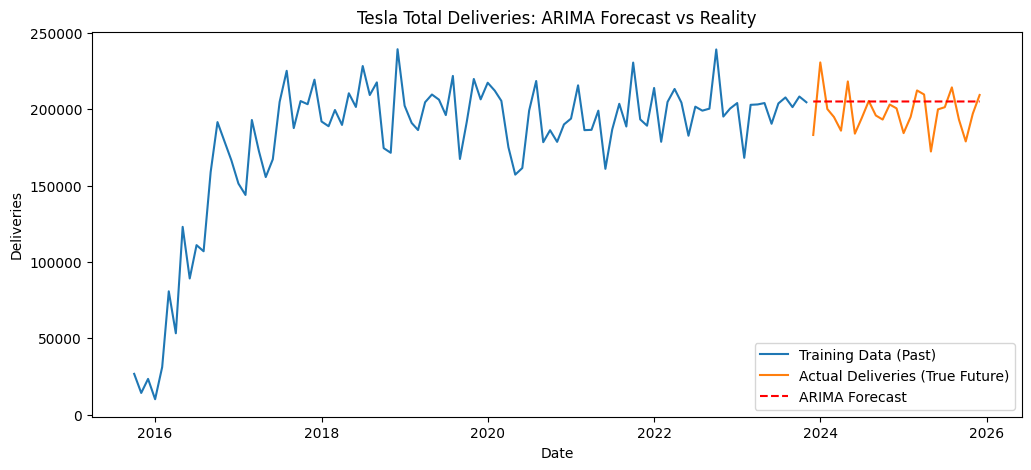

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

#ARIMA needs a single continuous timeline.
#We group the entire dataframe by Date to get Total Monthly Deliveries.
arima_series = df.groupby("Date")["Estimated_Deliveries"].sum()
arima_series = arima_series.asfreq('MS')

#Split into Train (80%) and Test (20%) using the exact same ratio
split_idx = int(len(arima_series) * 0.8)
arima_train = arima_series.iloc[:split_idx]
arima_test = arima_series.iloc[split_idx:]

# Order parameters:
# p=1 (looks at last month's value)
# d=1 (subtracts values to make data steady/stationary)
# q=1 (smooths out past prediction errors)
model = ARIMA(arima_train, order=(1, 1, 1))
model_fitted = model.fit()

# Forecast forward for the exact number of months in our test set
forecast_steps = len(arima_test)
arima_forecast = model_fitted.forecast(steps=forecast_steps)


#CALCULATE ARIMA METRICS
arima_mae = mean_absolute_error(arima_test, arima_forecast)
arima_mse = mean_squared_error(arima_test, arima_forecast)
arima_rmse = np.sqrt(arima_mse)
arima_r2 = r2_score(arima_test, arima_forecast)

print("Evaluation metrics for ARIMA forecasting")
print("MAE :", arima_mae)
print("MSE :", arima_mse)
print("RMSE:", arima_rmse)
print("R2 Score:", arima_r2)
print()


#PLOT THE FORECAST RESULT
plt.figure(figsize=(12, 5))
plt.plot(arima_train.index, arima_train, label="Training Data (Past)")
plt.plot(arima_test.index, arima_test, label="Actual Deliveries (True Future)")
plt.plot(arima_test.index, arima_forecast, label="ARIMA Forecast", linestyle="--", color="red")
plt.title("Tesla Total Deliveries: ARIMA Forecast vs Reality")
plt.xlabel("Date")
plt.ylabel("Deliveries")
plt.legend()
plt.show()
